## Лабораторная работа 2 "Пороговый детектор на заданной полосе частот"

### Импорты

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import librosa

Загрузка wav файла и визуализация

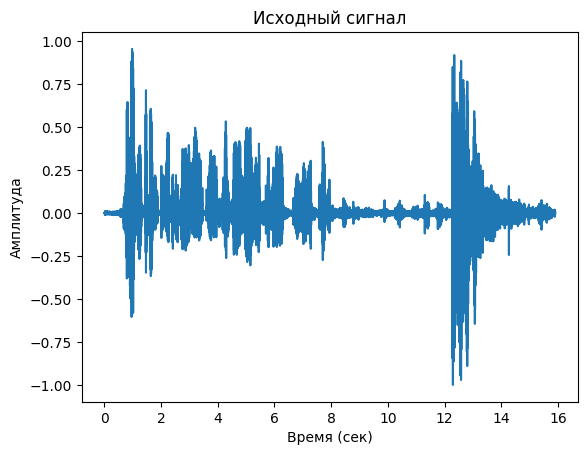

In [ ]:
signal, sr = librosa.load("Стрельба на улице.wav", sr=None)

signal = signal / np.max(np.abs(signal))

time = np.arange(len(signal)) / sr

plt.figure()
plt.title("Исходный сигнал")
plt.plot(time, signal)
plt.xlabel("Время (сек)")
plt.ylabel("Амплитуда")
plt.show()

Разбиваем на секундные окна

In [ ]:
window_size = sr
num_windows = len(signal) // window_size

windows = []

for i in range(num_windows):
    w = signal[i*window_size:(i+1)*window_size]
    windows.append(w)

print("Количество окон:", num_windows)

Количество окон: 15


Делаем преобразование Фурье каждого окна

In [ ]:
spectra = []
freqs = np.fft.rfftfreq(window_size, 1/sr)

for w in windows:
    spectrum = np.fft.rfft(w)
    amplitude = np.abs(spectrum)
    spectra.append(amplitude)

Смотрим спектры всех окон

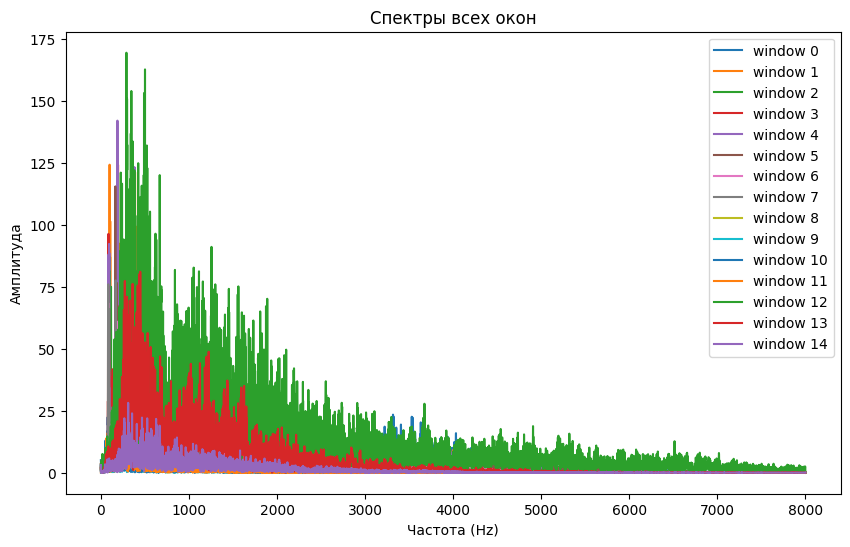

In [5]:
plt.figure(figsize=(10,6))

for i, spec in enumerate(spectra):

    amplitude = np.abs(spec)

    plt.plot(freqs, amplitude, label=f"window {i}")

plt.title("Спектры всех окон")
plt.xlabel("Частота (Hz)")
plt.ylabel("Амплитуда")
plt.legend()
plt.show()

Видно что амплитуда и частота спектра 12 сильно отличается

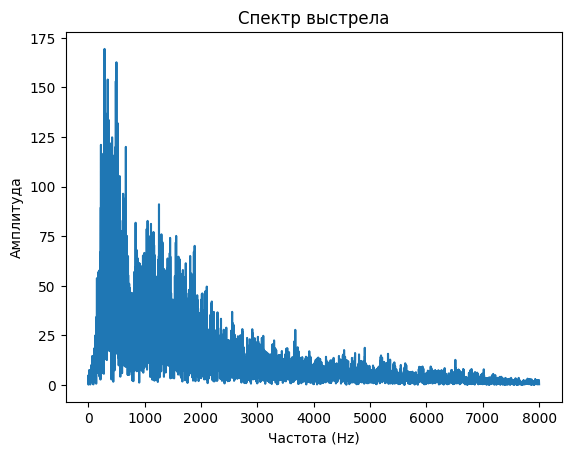

In [6]:
shot_window = 12

amplitude = np.abs(spectra[shot_window])

plt.figure()
plt.title("Спектр выстрела")
plt.plot(freqs, amplitude)
plt.xlabel("Частота (Hz)")
plt.ylabel("Амплитуда")
plt.show()

Создаем частотный фильтр

In [7]:
f_low = 500
f_high = 4000

mask = (freqs > f_low) & (freqs < f_high)

In [8]:
energies = []

for spec in spectra:

    band_energy = np.sum(spec[mask]**2)

    energies.append(band_energy)

energies = np.array(energies)

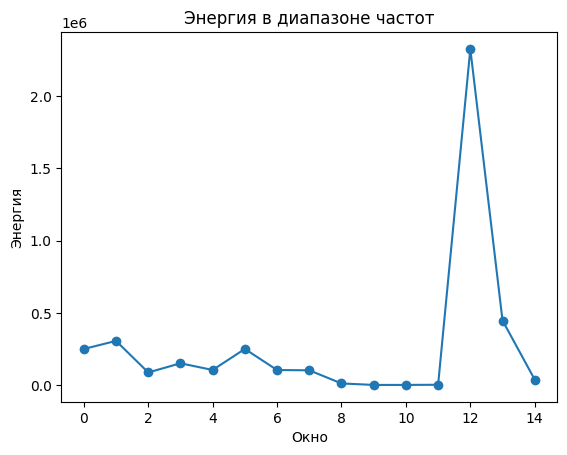

In [9]:
plt.figure()
plt.plot(energies, marker='o')
plt.title("Энергия в диапазоне частот")
plt.xlabel("Окно")
plt.ylabel("Энергия")
plt.show()

In [10]:
filtered_spectra = []

for spec in spectra:
    filtered = spec * mask
    filtered_spectra.append(filtered)

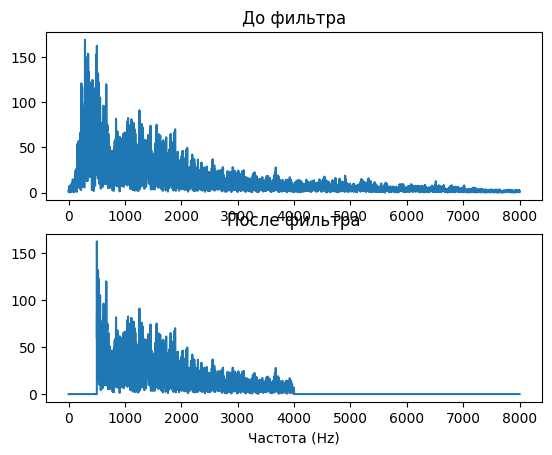

In [11]:
plt.figure()

plt.subplot(2,1,1)
plt.title("До фильтра")
plt.plot(freqs, np.abs(spectra[shot_window]))

plt.subplot(2,1,2)
plt.title("После фильтра")
plt.plot(freqs, np.abs(filtered_spectra[shot_window]))

plt.xlabel("Частота (Hz)")
plt.show()

Смотрим энергию аудиосигнала для каждого временного окна

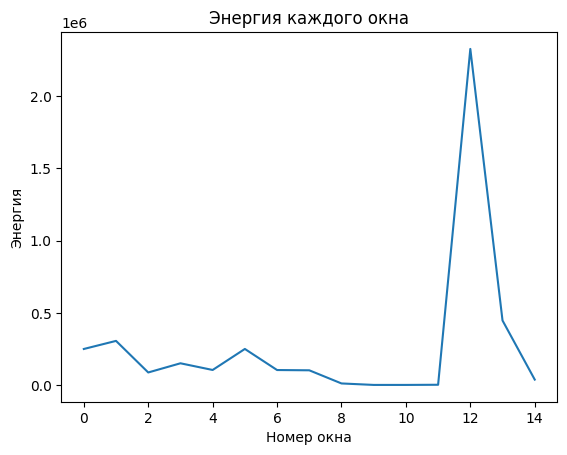

In [12]:
plt.figure()
plt.title("Энергия каждого окна")
plt.plot(energies)
plt.xlabel("Номер окна")
plt.ylabel("Энергия")
plt.show()

In [13]:
threshold = np.mean(energies) * 3

Выполняем простое обнаружение выстрела на основе энергии аудиосигнала

Если энергия окна превышает пороговое значение, считается, что в данном фрагменте сигнала присутствует искомое событие — в данном случае выстрел

In [14]:
detections = energies > threshold

for i, d in enumerate(detections):
    print(f"Окно {i}: ", "True (выстрел)" if d else "False")

Окно 0:  False
Окно 1:  False
Окно 2:  False
Окно 3:  False
Окно 4:  False
Окно 5:  False
Окно 6:  False
Окно 7:  False
Окно 8:  False
Окно 9:  False
Окно 10:  False
Окно 11:  False
Окно 12:  True (выстрел)
Окно 13:  False
Окно 14:  False


На данном графике показан результат детектирования выстрела на основе энергии аудиосигнала.

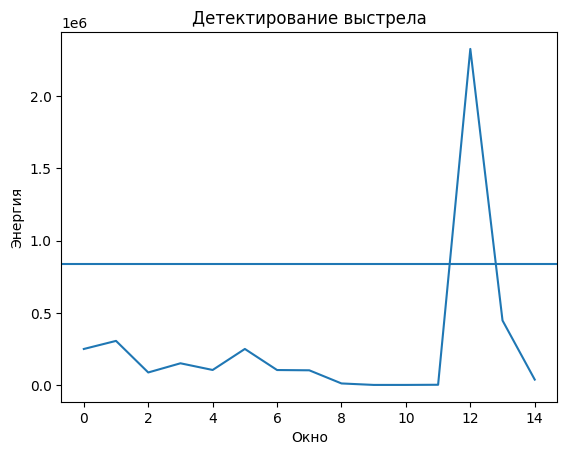

In [15]:
plt.figure()

plt.plot(energies)
plt.axhline(threshold)

plt.title("Детектирование выстрела")
plt.xlabel("Окно")
plt.ylabel("Энергия")

plt.show()

**Выводы** В ходе лабораторной работы был реализован простой алгоритм обнаружения акустического события (выстрела) в аудиосигнале. Сигнал был разделён на временные окна, для каждого окна вычислялся спектр с помощью быстрого преобразования Фурье (FFT). Далее анализировалась энергия сигнала в заданном частотном диапазоне, характерном для выстрела. На основе полученной энергии был задан порог, превышение которого позволяло определить наличие акустического события в соответствующем окне. В результате было показано, что анализ спектральной энергии в определённом диапазоне частот позволяет обнаруживать кратковременные акустические события в аудиосигнале.